# EZ-STANCE Claim-Only — LLMs vs Paper Baselines

Evaluates LLMs on the **EZ-STANCE Subtask A claim-only test rows** (5,135 documents, 3 classes: FAVOR / AGAINST / NONE).
Claim targets only (filtered from the mixed test set), spanning 8 domains.

**Paper baselines** from Table 7 of Zhao & Caragea (ACL 2024):
No dedicated C→C (claim-train, claim-test) split is reported in the paper.
The closest reference is the **M→M column** (trained + tested on mixed, which includes claim rows).
Best M→M model: **BART-MNLI-eₚ = 0.812** (macro F1).

> Per-class baseline numbers are not available for a claim-only split; class-level reference lines are omitted.

## Step 1: Imports

In [1]:
import os
from pathlib import Path
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

## Step 2: Config

In [ ]:
# ── Paths ─────────────────────────────────────────────────────────────────
_rd = [Path("../data_out/stance/ezstance_test_mixed"), Path("data_out/stance/ezstance_test_mixed")]
RESULTS_DIR = next(p for p in _rd if p.exists())
print("RESULTS_DIR:", RESULTS_DIR.resolve())

_gd = [Path("../data_in/ezstance/ezstance_test_mixed.csv"), Path("data_in/ezstance/ezstance_test_mixed.csv")]
GOLD_CSV = next(p for p in _gd if p.exists())
print("GOLD_CSV:   ", GOLD_CSV.resolve())

# ── Claim-only filter ──────────────────────────────────────────────────────
import pandas as _gold_pd
_gold_full = _gold_pd.read_csv(GOLD_CSV)
CLAIM_IDS  = set(
    _gold_full[_gold_full["source_dataset"] == "EZStance-SubtaskA-Claim-test"]["id"].astype(str)
)
print(f"Claim-only IDs: {len(CLAIM_IDS)} (of {len(_gold_full)} total)")

# Both vLLM and GPT results live in RESULTS_DIR; prefixes differ by dataset tag
VLLM_PREFIX = "GenAIStanceOneShot_7798_ezstance_mixed_"
GPT_PREFIX  = "GenAIStanceOneShot_7798_ezstance_test_mixed_"
KNOWN_PREFIXES = [VLLM_PREFIX, GPT_PREFIX]

LABELS  = ["FAVOR", "AGAINST", "NONE"]
CLASSES = LABELS

PROMPT_ORDER = [
    "default_no_label_definitions",
    "default",
    "task_definition",
    "question",
    "cot",
    "task_definition_scale",
    "few_shot_3",
    "few_shot_6",
    "few_shot_9",
    "few_shot_12",
    "few_shot_15",
]

PROMPT_LABELS_CHART = {
    "default_no_label_definitions": "No-def",
    "default":                      "Default",
    "task_definition":              "Task-def",
    "question":                     "Question",
    "cot":                          "CoT",
    "task_definition_scale":        "Scale",
    "few_shot_3":  "3R",
    "few_shot_6":  "6R",
    "few_shot_9":  "9R",
    "few_shot_12": "12R",
    "few_shot_15": "15R",
}

# ── Model ordering: GPT first, then open models by size descending ─────────
MODEL_ORDER = [
    # Proprietary
    "gpt-5.2",
    "gpt-5-mini",
    "claude-haiku-4-5-20251001",
    # 14B
    "DeepSeek-R1-Distill-Qwen-14B",
    "Qwen3-14B",
    "phi-4",
    # 8B
    "Qwen3-8B",
    "DeepSeek-R1-Distill-Llama-8B",
    "Llama-3.1-8B-Instruct",
    # 4B
    "Qwen3-4B",
    "Qwen3-4B-Instruct-2507",
    "Nemotron-Mini-4B-Instruct",
    # 3.8B
    "phi-4-mini-instruct",
    # 1.7B
    "Qwen3-1.7B",
]

def _ordered_models(df_or_series, col="model"):
    """Return MODEL_ORDER entries that are present in df_or_series[col]."""
    if hasattr(df_or_series, "unique"):
        vals = set(df_or_series.unique())
    else:
        vals = set(df_or_series[col].apply(
            lambda m: m.split("/")[-1] if "/" in m else m
        ).unique())
    return [m for m in MODEL_ORDER if m in vals]

# Paper baselines — Table 7, M→M column (closest reference; no C→C in paper)
PAPER_BASELINES = OrderedDict([
    ("BiCE",           0.468),
    ("Cross-Net",      0.518),
    ("TGA-Net",        0.590),
    ("LLaMA2 (ZS)",    0.404),
    ("ChatGPT (ZS)",   0.499),
    ("RoBERTa",        0.784),
    ("RoBERTa-MNLI",   0.797),
    ("RoBERTa-MNLI_p", 0.799),
    ("BART-MNLI",      0.664),
    ("BART-MNLI-e",    0.810),
    ("BART-MNLI-ep",   0.812),
])

BEST_PAPER_F3 = PAPER_BASELINES["BART-MNLI-ep"]
CHATGPT_F3    = PAPER_BASELINES["ChatGPT (ZS)"]

# Claim-only test label distribution (n=5135: FAVOR=1712, AGAINST=1712, NONE=1711)
GOLD_DIST = {"FAVOR": 1712/5135, "AGAINST": 1712/5135, "NONE": 1711/5135}

CLASS_COLORS = {"FAVOR": "#4C9BE8", "AGAINST": "#E8694C", "NONE": "#6DBF67"}

DOMAIN_NAMES = {
    "CE": "Covid\nEpidemic", "WE": "World\nEvents",
    "EdC": "Educ &\nCulture", "EnC": "Entertain &\nConsumption",
    "S": "Sports", "R": "Rights", "EP": "Environ\nProtect", "P": "Politics",
}
DOMAIN_ORDER = ["CE", "WE", "EdC", "EnC", "S", "R", "EP", "P"]

CANON_MAP = {"PRO": "FAVOR", "NEUTRAL": "NONE", "UNCLEAR": "NONE", "UNRELATED": "NONE"}

def canonicalize(s):
    s = str(s).upper().strip()
    return CANON_MAP.get(s, s)

def extract_model_prompt(folder):
    for pfx in KNOWN_PREFIXES:
        if folder.startswith(pfx):
            stem  = folder[len(pfx):]
            parts = stem.rsplit("_equal_", 1)
            if len(parts) == 2:
                return parts[0], parts[1]
    return None, None

print("Best paper F3 (BART-MNLI-ep, M→M reference):", BEST_PAPER_F3)

## Step 3: Load LLM Results

In [3]:
llm_rows = []

for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_7798"):
        continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists():
        continue
    model, prompt = extract_model_prompt(folder)
    if model is None or prompt not in PROMPT_ORDER:
        continue

    df = pd.read_csv(csv_path)
    # ── Keep only claim-only rows ──────────────────────────────────────
    df = df[df["doc_id"].astype(str).isin(CLAIM_IDS)].copy()

    df["original_stance"] = df["original_stance"].astype(str).str.upper().str.strip()
    df = df[df["original_stance"].isin(CLASSES)].copy()
    df["predicted_stance"] = df["predicted_stance"].apply(
        lambda x: canonicalize(x) if pd.notna(x) else None
    )
    df = df[df["predicted_stance"].isin(CLASSES)]
    if len(df) < 100:
        print(f"  SKIP {folder}: only {len(df)} valid rows")
        continue

    yt = df["original_stance"].tolist()
    yp = df["predicted_stance"].tolist()
    prec, rec, f1, _ = precision_recall_fscore_support(
        yt, yp, labels=CLASSES, zero_division=0
    )
    macro_f1 = f1.mean()
    vc = pd.Series(yp).value_counts()

    llm_rows.append({
        "model":           model,
        "prompt":          prompt,
        "3class_macro_f1": macro_f1,
        "f_favor":         f1[0],
        "f_against":       f1[1],
        "f_none":          f1[2],
        "p_favor":         prec[0],
        "p_against":       prec[1],
        "p_none":          prec[2],
        "r_favor":         rec[0],
        "r_against":       rec[1],
        "r_none":          rec[2],
        "pred_favor":      vc.get("FAVOR",   0),
        "pred_against":    vc.get("AGAINST", 0),
        "pred_none":       vc.get("NONE",    0),
        "n_valid":         len(df),
    })

llm_df = pd.DataFrame(llm_rows)
print(f"Total experiment rows: {len(llm_df)}")
print(f"Models:  {sorted(llm_df['model'].unique())}")
print(f"Prompts: {sorted(llm_df['prompt'].unique())}")

Total experiment rows: 143
Models:  ['DeepSeek-R1-Distill-Llama-8B', 'DeepSeek-R1-Distill-Qwen-14B', 'Llama-3.1-8B-Instruct', 'Nemotron-Mini-4B-Instruct', 'Qwen3-1.7B', 'Qwen3-14B', 'Qwen3-4B', 'Qwen3-4B-Instruct-2507', 'Qwen3-8B', 'gpt-5-mini', 'gpt-5.2', 'phi-4', 'phi-4-mini-instruct']
Prompts: ['cot', 'default', 'default_no_label_definitions', 'few_shot_12', 'few_shot_15', 'few_shot_3', 'few_shot_6', 'few_shot_9', 'question', 'task_definition', 'task_definition_scale']


## Step 3b: Training & Test Label Distribution

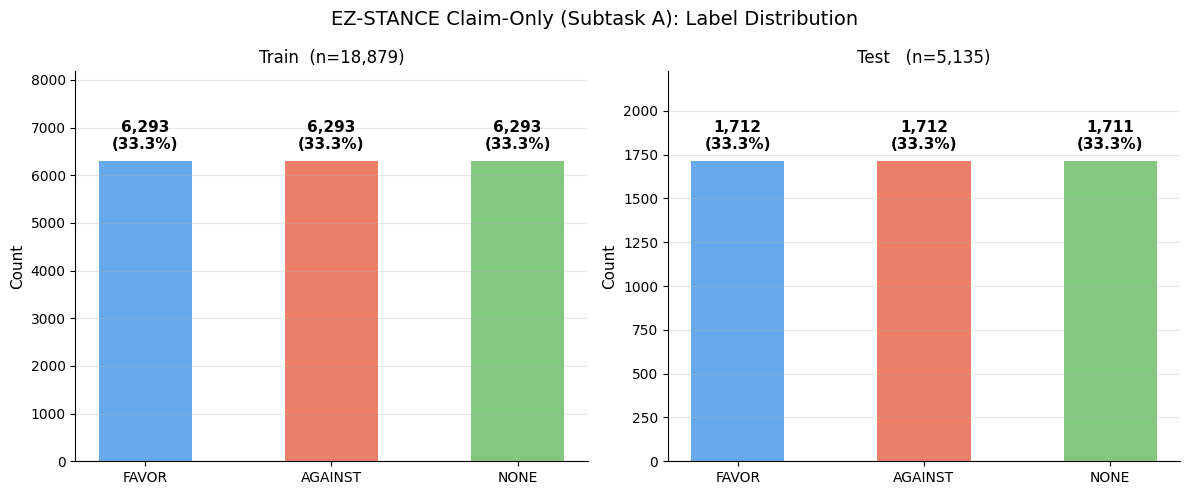

In [4]:
def _find(rel, alt):
    return Path(rel) if Path(rel).exists() else Path(alt)

CLAIM_TRAIN_CSV = _find("../data_in/raw/ezstance/subtaskA/claim/raw_train_all_onecol.csv",
                            "data_in/raw/ezstance/subtaskA/claim/raw_train_all_onecol.csv")

claim_train = pd.read_csv(CLAIM_TRAIN_CSV)
# Test set: filter the mixed gold CSV to claim-only rows
claim_test  = pd.read_csv(GOLD_CSV)
claim_test  = claim_test[claim_test["source_dataset"] == "EZStance-SubtaskA-Claim-test"]

COLORS = {"FAVOR": "#4C9BE8", "AGAINST": "#E8694C", "NONE": "#6DBF67"}

def label_counts(df, col):
    vc = df[col].str.upper().str.strip().value_counts()
    return {lbl: vc.get(lbl, 0) for lbl in LABELS}

splits = [
    (0, label_counts(claim_train, "Stance 1"),              f"Train  (n={len(claim_train):,})"),
    (1, label_counts(claim_test,  "stance_label_original"), f"Test   (n={len(claim_test):,})"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for col, counts, title in splits:
    ax     = axes[col]
    total  = sum(counts.values())
    values = [counts[l] for l in LABELS]
    colors = [COLORS[l] for l in LABELS]
    bars   = ax.bar(LABELS, values, color=colors, alpha=0.85, width=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + total * 0.01,
                f"{val:,}\n({val/total:.1%})",
                ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_ylim(0, max(values) * 1.3)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("EZ-STANCE Claim-Only (Subtask A): Label Distribution", fontsize=14)
plt.tight_layout()
plt.show()

## Step 4: Pooled Metrics

In [5]:
best_idx  = llm_df["3class_macro_f1"].idxmax()
worst_idx = llm_df["3class_macro_f1"].idxmin()

print("=== Pooled 3-class Macro F1 (all model×prompt) ===")
print(f"  Mean:  {llm_df['3class_macro_f1'].mean():.4f}")
print(f"  Best:  {llm_df.loc[best_idx, '3class_macro_f1']:.4f}  "
      f"({llm_df.loc[best_idx, 'model']} | {llm_df.loc[best_idx, 'prompt']})")
print(f"  Worst: {llm_df.loc[worst_idx, '3class_macro_f1']:.4f}  "
      f"({llm_df.loc[worst_idx, 'model']} | {llm_df.loc[worst_idx, 'prompt']})")
print()
print(f"Paper best (BART-MNLI-ep, M→M): {BEST_PAPER_F3:.4f}")
print(f"Paper ChatGPT (zero-shot):       {CHATGPT_F3:.4f}")

=== Pooled 3-class Macro F1 (all model×prompt) ===
  Mean:  0.4451
  Best:  0.6125  (gpt-5.2 | default)
  Worst: 0.1667  (Nemotron-Mini-4B-Instruct | task_definition_scale)

Paper best (BART-MNLI-ep, M→M): 0.8120
Paper ChatGPT (zero-shot):       0.4990


## Step 5: Chart — 3-class Macro F1 vs Paper Baselines

Baseline = EZ-STANCE paper Table 7 (M→M, trained+tested on mixed targets).
Fine-tuned best: **BART-MNLI-eₚ = 0.812**. Zero-shot LLMs from paper: ChatGPT 0.499, LLaMA2 0.404.

In [ ]:
available_prompts = [p for p in PROMPT_ORDER if p in llm_df["prompt"].unique()]
x_labels = [PROMPT_LABELS_CHART[p] for p in available_prompts]
x_pos    = list(range(len(available_prompts)))

models = _ordered_models(llm_df)
cmap   = plt.cm.get_cmap("tab20", max(len(models), 2))

fig, ax = plt.subplots(figsize=(max(14, len(available_prompts) * 1.1), 6))

for i, model in enumerate(models):
    mdf = llm_df[llm_df["model"] == model].set_index("prompt")
    y = [mdf.loc[p, "3class_macro_f1"] if p in mdf.index else float("nan")
         for p in available_prompts]
    short = model.split("/")[-1] if "/" in model else model
    ax.plot(x_pos, y, marker="o", linewidth=1.8, markersize=5,
            label=short, color=cmap(i))

# Best supervised baseline per training/testing configuration — Table 7, Subtask A
key_baselines = [
    ("M\u2192M ref (train+test mixed, incl. claims)", 0.812, "green", "-."),
]
for name, val, col, ls in key_baselines:
    ax.axhline(val, color=col, linestyle=ls, linewidth=1.4, alpha=0.85,
               label=f"{name} ({val:.3f})")

if "task_definition_scale" in available_prompts and "few_shot_3" in available_prompts:
    sx = (available_prompts.index("task_definition_scale") +
          available_prompts.index("few_shot_3")) / 2
    ax.axvline(sx, color="grey", linestyle=":", linewidth=1)
    for j, lbl in enumerate(["Zero-shot", "Random ICL"]):
        mid = ([-0.5, sx][j] + [sx, len(available_prompts) - 0.5][j]) / 2
        ax.text(mid, -0.085, lbl, ha="center", fontsize=8, color="grey",
                transform=ax.get_xaxis_transform())

ax.set_ylim(0, 1)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, fontsize=9)
ax.set_ylabel("3-class Macro F1", fontsize=11)
ax.set_title(
    "3-class Macro F1: LLMs vs EZ-STANCE Paper Baselines (Table 7, Subtask A)\n5,135 claim-only test docs  |  M\u2192M ref = 0.812 (no dedicated C\u2192C baseline in paper)",
    fontsize=12,
)
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Step 6: Numerical Tables

**Table I** — per-model summary: mean / best / std F3 across all prompts.
**Table II** — per-model × prompt: F3 and per-class F1.

In [ ]:
summary = (
    llm_df.groupby("model")
    .agg(
        mean_f3=("3class_macro_f1", "mean"),
        best_f3=("3class_macro_f1", "max"),
        std_f3 =("3class_macro_f1", "std"),
    )
    .reset_index()
    .sort_values("mean_f3", ascending=False)
)
summary["model_short"] = summary["model"].apply(lambda m: m.split("/")[-1] if "/" in m else m)

print("=== Table I: Per-model Summary ===")
print(f"{'Model':<42} {'mean_F3':>8} {'best_F3':>8} {'std_F3':>8}")
print("-" * 72)
for _, r in summary.iterrows():
    print(f"{r['model_short']:<42} {r['mean_f3']:>8.4f} {r['best_f3']:>8.4f} {r['std_f3']:>8.4f}")
print()
print(f"Paper best (BART-MNLI-ep, M→M):   {BEST_PAPER_F3:.4f}")
print(f"Paper ChatGPT (zero-shot, M→N):    {CHATGPT_F3:.4f}")

print("\n=== Table II: Per-model × Prompt ===")
tbl = llm_df.copy()
tbl["prompt_rank"]  = tbl["prompt"].map({p: i for i, p in enumerate(PROMPT_ORDER)})
tbl["model_short"]  = tbl["model"].apply(lambda m: m.split("/")[-1] if "/" in m else m)
tbl = tbl.sort_values(["model_short", "prompt_rank"])
cols = ["model_short", "prompt", "3class_macro_f1", "f_favor", "f_against", "f_none"]
print(tbl[cols].to_string(index=False, float_format="{:.4f}".format))

=== Table I: Per-model Summary ===
Model                                       mean_F3  best_F3   std_F3
------------------------------------------------------------------------
gpt-5.2                                      0.5637   0.6034   0.0246
gpt-5-mini                                   0.5537   0.5874   0.0514
Qwen3-14B                                    0.5451   0.5949   0.0846
phi-4                                        0.5074   0.5815   0.0441
DeepSeek-R1-Distill-Qwen-14B                 0.5073   0.5455   0.0250
Qwen3-8B                                     0.5047   0.5532   0.0723
Qwen3-4B                                     0.4933   0.5451   0.0714
Qwen3-4B-Instruct-2507                       0.4675   0.5108   0.0441
phi-4-mini-instruct                          0.4606   0.4907   0.0194
DeepSeek-R1-Distill-Llama-8B                 0.4510   0.4832   0.0219
Qwen3-1.7B                                   0.4184   0.4540   0.0634
Nemotron-Mini-4B-Instruct                    0.4088 

## Step 7: Per-class Precision / Recall / F1 — by Prompt

3 × 3 grid: **rows** = class (FAVOR, AGAINST, NONE), **columns** = metric (Precision, Recall, F1).
No class-level paper baseline available for this M→M setting.

/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_19259/162732542.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("tab20", len(models))


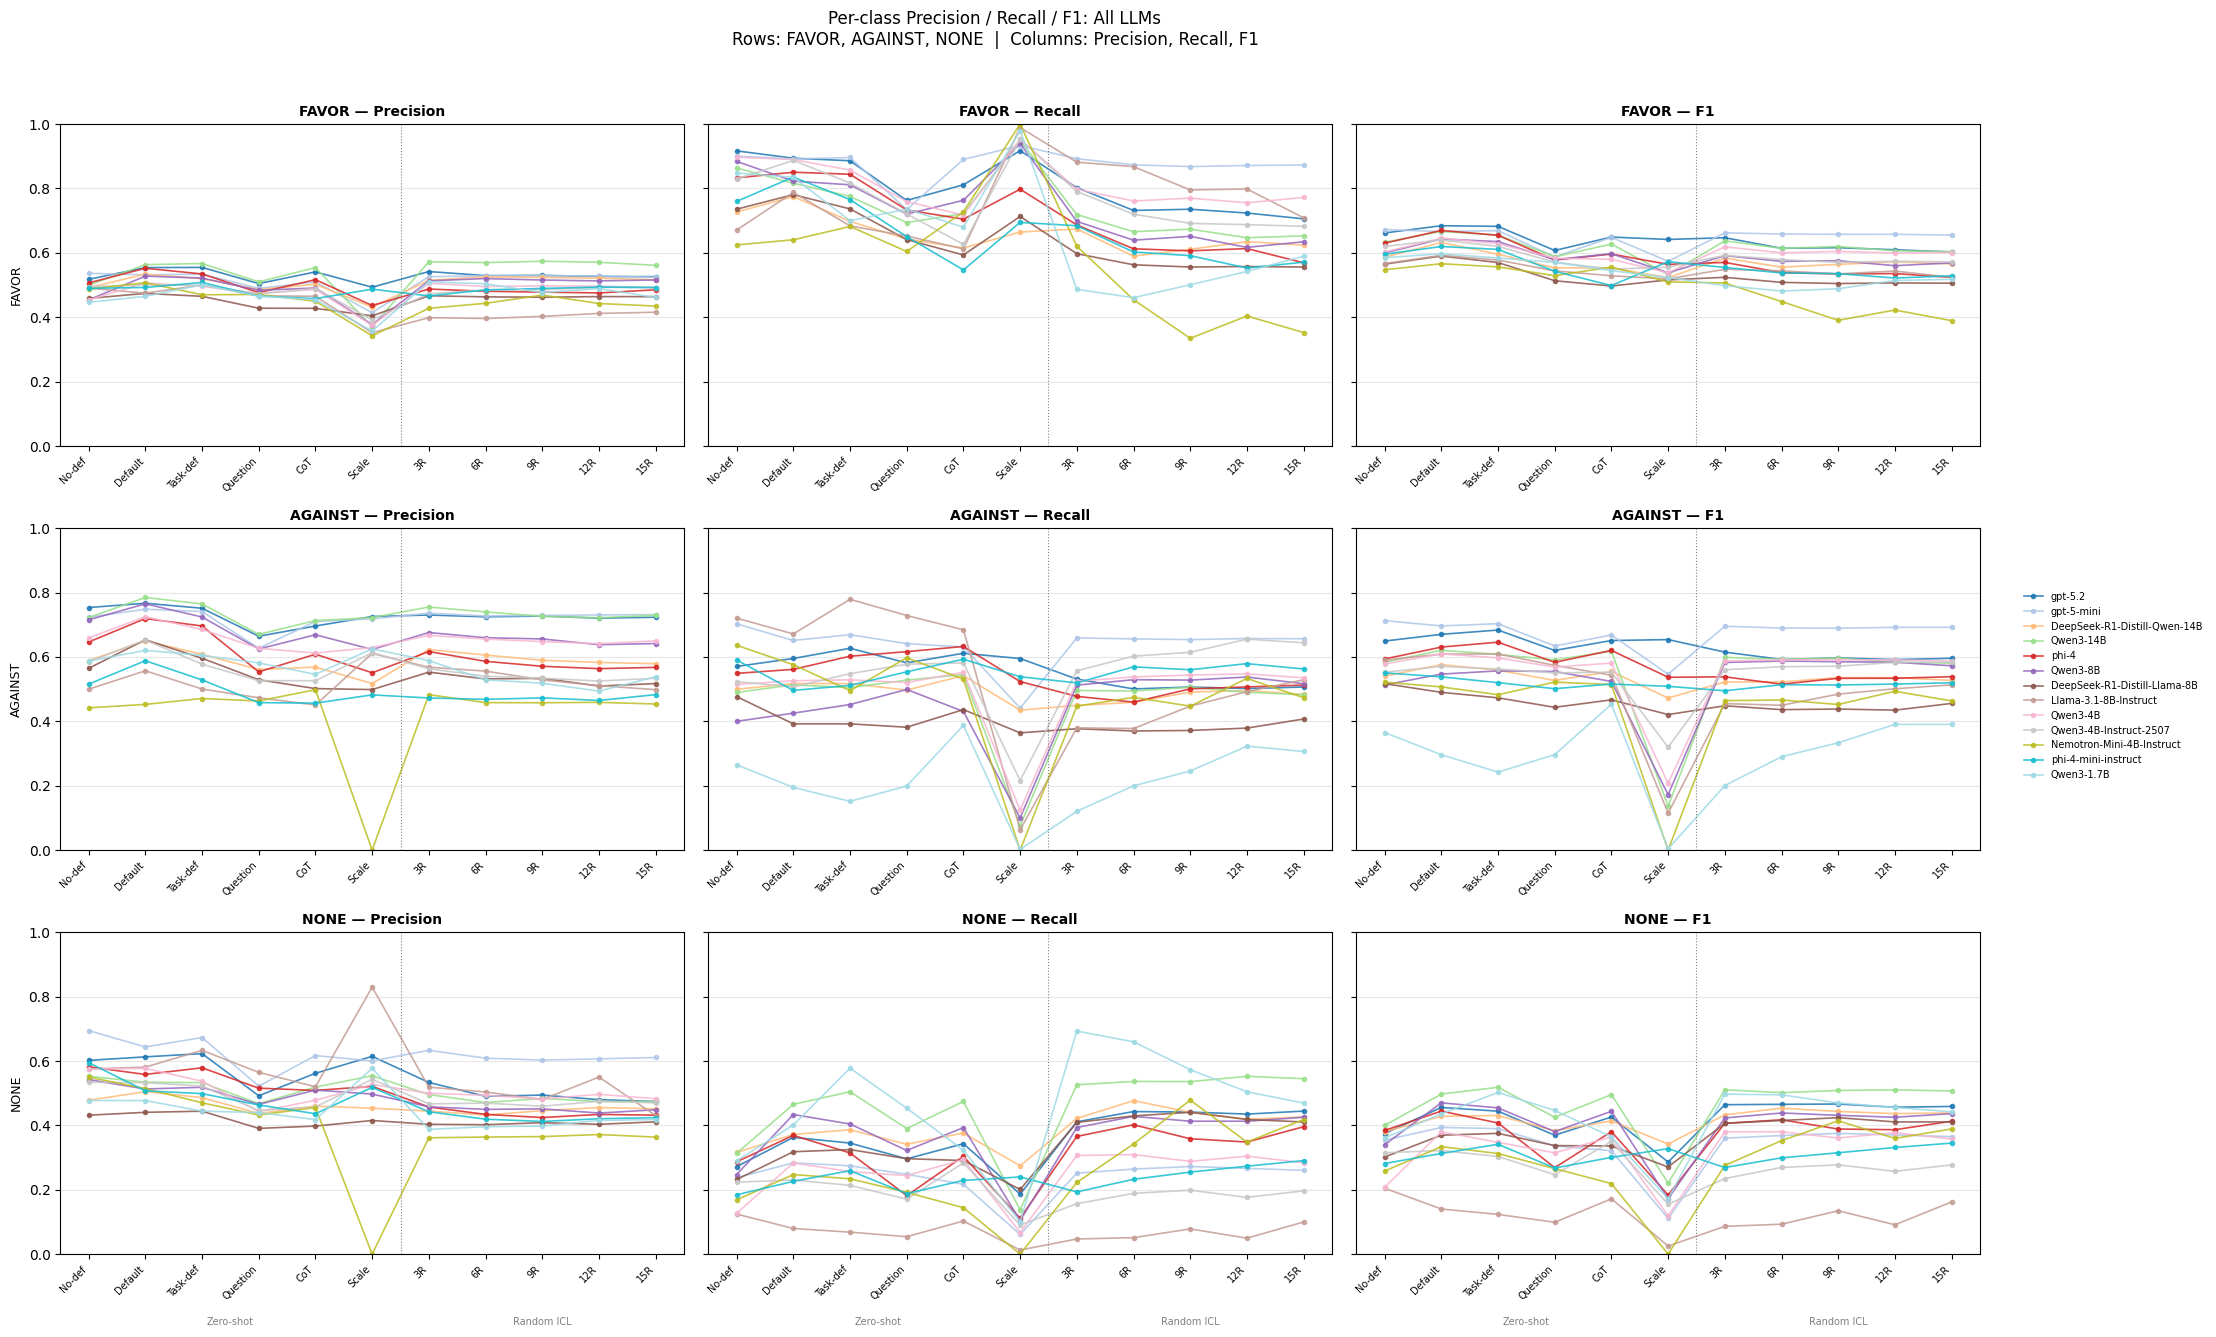

In [ ]:
METRICS = [("p", "Precision"), ("r", "Recall"), ("f", "F1")]

available_prompts = [p for p in PROMPT_ORDER if p in llm_df["prompt"].unique()]
x_pos    = list(range(len(available_prompts)))
x_labels = [PROMPT_LABELS_CHART[p] for p in available_prompts]

models = _ordered_models(llm_df)
cmap   = plt.cm.get_cmap("tab20", len(models))

fig, axes = plt.subplots(3, 3, figsize=(20, 13), sharey="row")

for row_idx, cls in enumerate(CLASSES):
    for col_idx, (metric_key, metric_label) in enumerate(METRICS):
        ax = axes[row_idx][col_idx]
        col_name = f"{metric_key}_{cls.lower()}"

        for i, model in enumerate(models):
            mdf   = llm_df[llm_df["model"] == model].set_index("prompt")
            y     = [mdf.loc[p, col_name] if p in mdf.index else float("nan")
                     for p in available_prompts]
            short = model.split("/")[-1] if "/" in model else model
            ax.plot(x_pos, y, marker="o", linewidth=1.2, markersize=3,
                    label=short, color=cmap(i), alpha=0.85)

        # Zero-shot / Random ICL separator
        if "task_definition_scale" in available_prompts and "few_shot_3" in available_prompts:
            sx = (available_prompts.index("task_definition_scale") +
                  available_prompts.index("few_shot_3")) / 2
            ax.axvline(sx, color="grey", linestyle=":", linewidth=0.8)

        ax.set_ylim(0, 1)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(x_labels, fontsize=7, rotation=45, ha="right")
        ax.set_title(f"{cls} — {metric_label}", fontsize=10, fontweight="bold")
        ax.grid(axis="y", alpha=0.3)
        if col_idx == 0:
            ax.set_ylabel(cls, fontsize=9)

handles, leg_labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, leg_labels, bbox_to_anchor=(1.01, 0.5),
           loc="center left", fontsize=7, frameon=False)

# Group labels on bottom row
boundaries = [-0.5]
if "task_definition_scale" in available_prompts and "few_shot_3" in available_prompts:
    boundaries.append((available_prompts.index("task_definition_scale") +
                       available_prompts.index("few_shot_3")) / 2)
boundaries.append(len(available_prompts) - 0.5)
group_names = ["Zero-shot", "Random ICL"]
for col_idx in range(3):
    ax = axes[2][col_idx]
    for gi, glbl in enumerate(group_names):
        if gi < len(boundaries) - 1:
            mid = (boundaries[gi] + boundaries[gi + 1]) / 2
            ax.text(mid, -0.22, glbl, ha="center", fontsize=7, color="grey",
                    transform=ax.get_xaxis_transform())

fig.suptitle(
    "Per-class Precision / Recall / F1: All LLMs\n"
    "Rows: FAVOR, AGAINST, NONE  |  Columns: Precision, Recall, F1",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.show()

## Step 8: Per-class F1 — Model Comparison (mean ± std across prompts)

Three panels (FAVOR / AGAINST / NONE). Bar = mean class F1 across all prompts. Error bar = std.
No class-level paper baseline available for M→M setting.

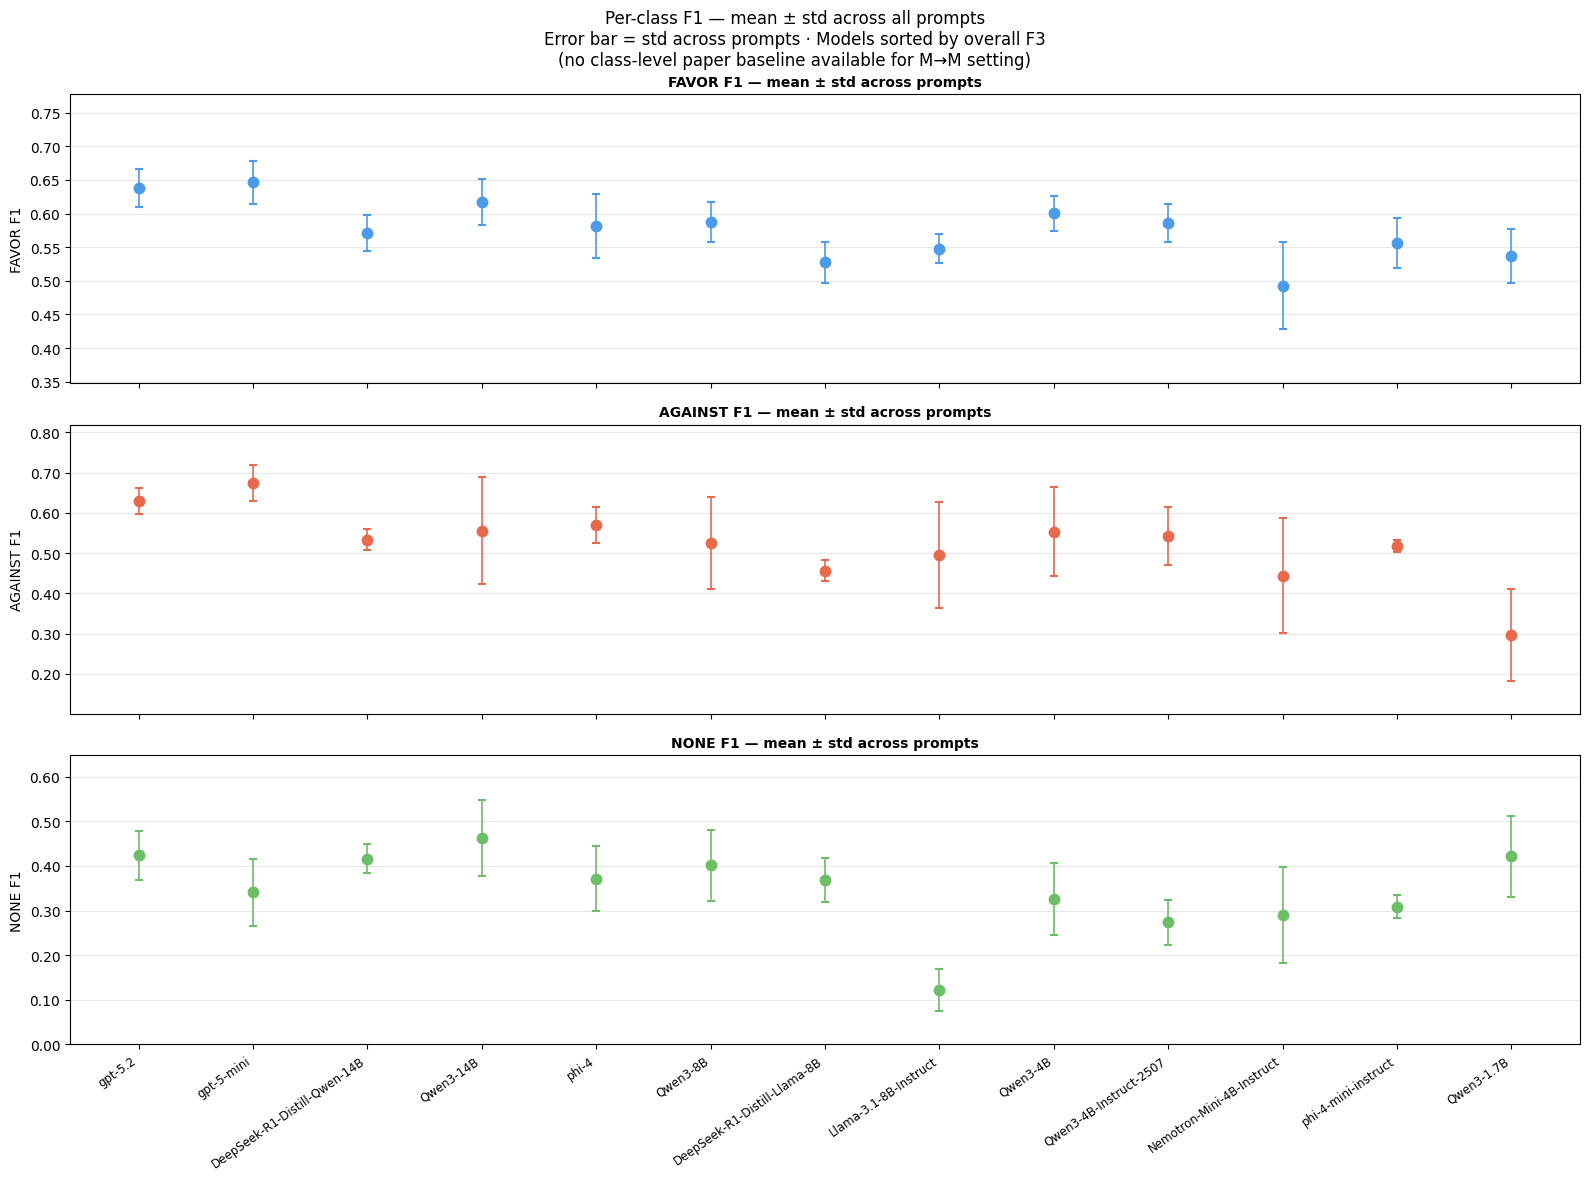

In [ ]:
CLASS_COLS  = {"FAVOR": "f_favor", "AGAINST": "f_against", "NONE": "f_none"}
CLASS_COLOR = {"FAVOR": "#4C9BE8", "AGAINST": "#E8694C",   "NONE": "#6DBF67"}

model_order = _ordered_models(llm_df)
model_labels = [m.split("/")[-1] if "/" in m else m for m in model_order]
x = np.arange(len(model_order))

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for row_idx, cls in enumerate(["FAVOR", "AGAINST", "NONE"]):
    ax    = axes[row_idx]
    col   = CLASS_COLS[cls]
    color = CLASS_COLOR[cls]

    means, stds = [], []
    for model in model_order:
        vals = llm_df[llm_df["model"] == model][col].values
        means.append(vals.mean())
        stds.append(vals.std())
    means = np.array(means)
    stds  = np.array(stds)

    ax.errorbar(x, means, yerr=stds, fmt="o", markersize=7,
                color=color, markeredgecolor=color, markeredgewidth=1.5,
                ecolor=color, elinewidth=1.2, capsize=3, zorder=3)

    ax.set_ylabel(f"{cls} F1", fontsize=10)
    ax.set_ylim(max(0, (means - stds).min() - 0.08), min(1, (means + stds).max() + 0.1))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.2f}"))
    ax.grid(axis="y", alpha=0.3)
    ax.set_title(f"{cls} F1 — mean ± std across prompts", fontsize=10, fontweight="bold")

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(model_labels, rotation=35, ha="right", fontsize=8.5)

fig.suptitle(
    "Per-class F1 — mean ± std across all prompts\n"
    "Error bar = std across prompts · Models sorted by overall F3\n"
    "(no class-level paper baseline available for M→M setting)",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Step 9: Precision vs Recall Scatter — per class

Each dot = one model × prompt combination, coloured by model.
Grey curves = F1 iso-contours (0.2, 0.4, 0.6, 0.8). Dashed diagonal = P = R.
No paper-baseline stars (class-level not available for M→M).

/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_19259/2174058824.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap        = plt.cm.get_cmap("tab20", len(models))


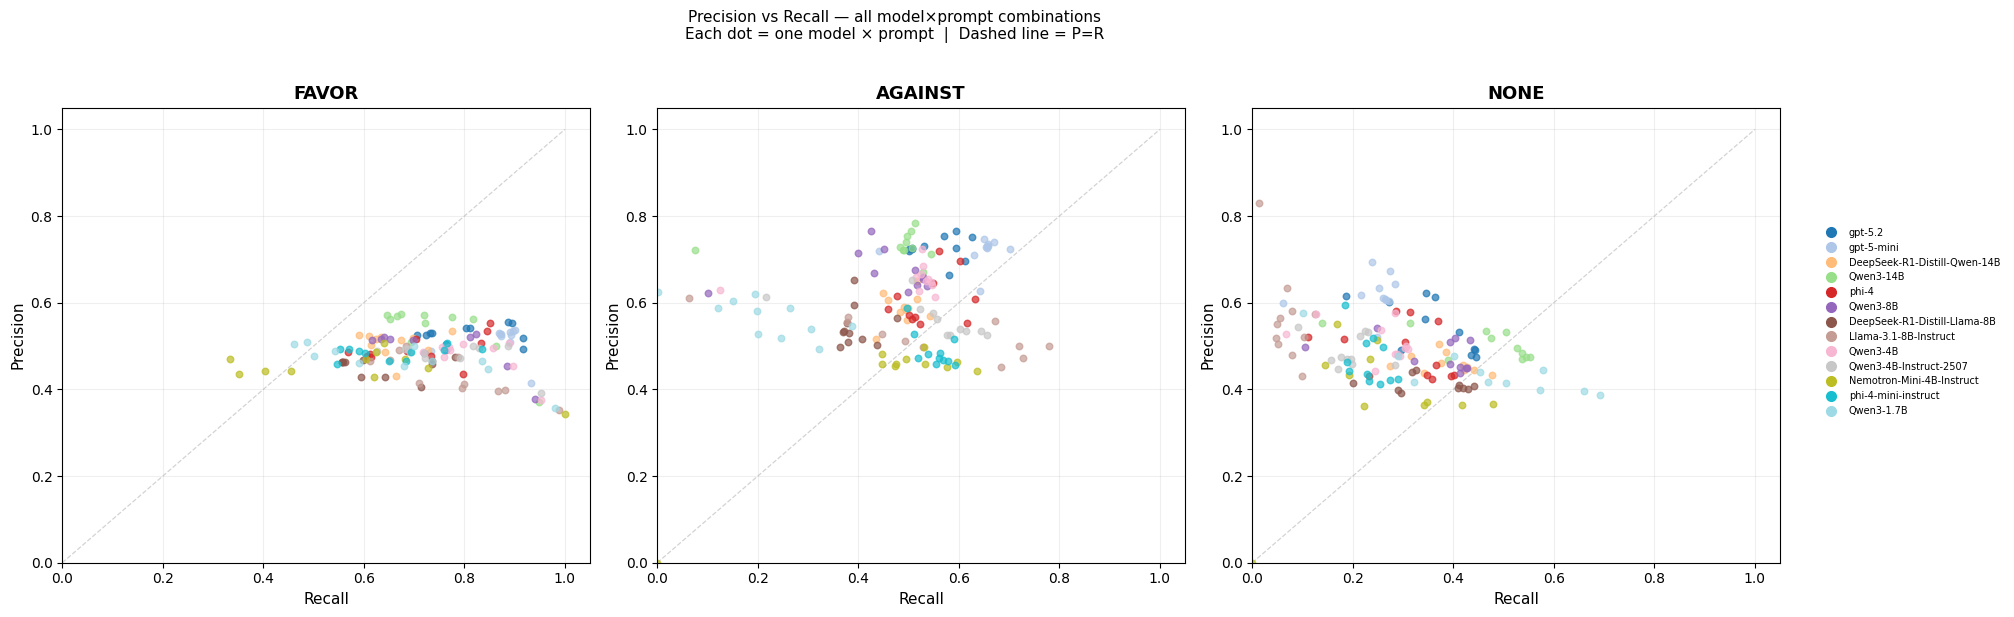

In [ ]:
models      = _ordered_models(llm_df)
cmap        = plt.cm.get_cmap("tab20", len(models))
model_color = {m: cmap(i) for i, m in enumerate(models)}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for col_idx, cls in enumerate(CLASSES):
    ax    = axes[col_idx]
    p_col = f"p_{cls.lower()}"
    r_col = f"r_{cls.lower()}"

    # P = R diagonal
    ax.plot([0, 1], [0, 1], color="lightgrey", linestyle="--", linewidth=0.9, zorder=0)

    # LLM scatter — x=Recall, y=Precision (matches SemEval baseline convention)
    for model in models:
        mdf   = llm_df[llm_df["model"] == model]
        short = model.split("/")[-1] if "/" in model else model
        ax.scatter(mdf[r_col], mdf[p_col],
                   color=model_color[model], s=22, alpha=0.7, zorder=2, label=short)

    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Recall",    fontsize=11)
    ax.set_ylabel("Precision", fontsize=11)
    ax.set_title(cls, fontsize=13, fontweight="bold")
    ax.grid(alpha=0.2)

handles = [mlines.Line2D([], [], marker="o", linestyle="None",
                          color=model_color[m], markersize=7,
                          label=m.split("/")[-1] if "/" in m else m)
           for m in models]
fig.legend(handles=handles, bbox_to_anchor=(1.01, 0.5), loc="center left",
           fontsize=7, frameon=False)

fig.suptitle(
    "Precision vs Recall — all model×prompt combinations\n"
    "Each dot = one model × prompt  |  Dashed line = P=R",
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.show()

## Step 10: Predicted vs Gold Distribution — per class, per model across all prompts

Dots = per-prompt predicted fraction. Diamond = mean across prompts. Red line = gold test fraction.

In [ ]:
dist_rows = []
for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_7798"):
        continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists():
        continue
    model, prompt = extract_model_prompt(folder)
    if model is None or prompt not in PROMPT_ORDER:
        continue
    df = pd.read_csv(csv_path)
    df = df[df["doc_id"].astype(str).isin(CLAIM_IDS)].copy()
    df["predicted_stance"] = df["predicted_stance"].apply(
        lambda x: canonicalize(x) if pd.notna(x) else None
    )
    df = df[df["predicted_stance"].isin(CLASSES)]
    if len(df) == 0:
        continue
    vc = df["predicted_stance"].value_counts(normalize=True)
    dist_rows.append({
        "model": model, "prompt": prompt,
        "pred_favor":   vc.get("FAVOR",   0),
        "pred_against": vc.get("AGAINST", 0),
        "pred_none":    vc.get("NONE",    0),
        "model_short":  model.split("/")[-1] if "/" in model else model,
    })

dist_df = pd.DataFrame(dist_rows)

CLASS_COLS_D = {"FAVOR": "pred_favor", "AGAINST": "pred_against", "NONE": "pred_none"}
llm_models_sorted = _ordered_models(dist_df, "model_short")
x = np.arange(len(llm_models_sorted))
model_idx = {m: i for i, m in enumerate(llm_models_sorted)}

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)

for row_idx, cls in enumerate(["FAVOR", "AGAINST", "NONE"]):
    ax       = axes[row_idx]
    col      = CLASS_COLS_D[cls]
    gold_pct = GOLD_DIST[cls]
    color    = CLASS_COLORS[cls]

    for model in llm_models_sorted:
        mdf = dist_df[dist_df["model_short"] == model]
        xi  = model_idx[model]
        jitter = (np.random.default_rng(42).random(len(mdf)) - 0.5) * 0.35
        ax.scatter(xi + jitter, mdf[col], alpha=0.45, s=22, color=color, zorder=2)
        ax.scatter(xi, mdf[col].mean(), marker="D", s=70, color="black", zorder=4)

    ax.axhline(gold_pct, color="red", linestyle=":", linewidth=2,
               label=f"Gold {cls} = {gold_pct:.1%}")

    ax.set_ylabel("Predicted %", fontsize=10)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.set_title(f"{cls}  (gold = {gold_pct:.1%})", fontsize=11, fontweight="bold")
    ax.legend(fontsize=9, frameon=False, loc="upper right")
    ax.grid(axis="y", alpha=0.3)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels(llm_models_sorted, rotation=40, ha="right", fontsize=8)

fig.suptitle(
    "Predicted class % vs gold distribution\n"
    "Dots = individual prompts · Diamond = mean across prompts · Red line = gold %",
    fontsize=12,
)
plt.tight_layout()
plt.show()

## Step 11: Confusion Transition Analysis — Key Misclassifications

Six off-diagonal transitions: AGAINST→NONE, AGAINST→FAVOR, FAVOR→AGAINST, FAVOR→NONE, NONE→FAVOR, NONE→AGAINST.
**Table A** — per model, averaged across prompts. **Heatmap** — all model×prompt rows.

In [ ]:
KEY_TRANS = [
    "FAVOR→FAVOR",   "FAVOR→AGAINST",   "FAVOR→NONE",
    "AGAINST→FAVOR", "AGAINST→AGAINST", "AGAINST→NONE",
    "NONE→FAVOR",    "NONE→AGAINST",    "NONE→NONE",
]

cm_rows = []
for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_7798"):
        continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists():
        continue
    model, prompt = extract_model_prompt(folder)
    if model is None or prompt not in PROMPT_ORDER:
        continue

    df = pd.read_csv(csv_path)
    df = df[df["doc_id"].astype(str).isin(CLAIM_IDS)].copy()
    df["original_stance"]  = df["original_stance"].astype(str).str.upper().str.strip()
    df["predicted_stance"] = df["predicted_stance"].apply(
        lambda x: (lambda s: CANON_MAP.get(s, s))(str(x).upper().strip())
        if pd.notna(x) else None
    )
    df = df[df["original_stance"].isin(CLASSES) & df["predicted_stance"].isin(CLASSES)]
    if len(df) < 100:
        continue

    yt, yp  = df["original_stance"].tolist(), df["predicted_stance"].tolist()
    cm      = confusion_matrix(yt, yp, labels=CLASSES).astype(float)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    short   = model.split("/")[-1] if "/" in model else model

    row = {"model": model, "prompt": prompt, "model_short": short}
    for ri, tc in enumerate(CLASSES):
        for ci, pc in enumerate(CLASSES):
            row[f"{tc}→{pc}"] = cm_norm[ri, ci]
    cm_rows.append(row)

cm_df = pd.DataFrame(cm_rows)
cm_df["prompt_rank"] = cm_df["prompt"].map({p: i for i, p in enumerate(PROMPT_ORDER)})

# ── Table A + Heatmap A — per model (mean across prompts) ──────────────────
mean_cm = (
    cm_df.groupby("model_short")[KEY_TRANS].mean()
    .reindex([m for m in MODEL_ORDER if m in cm_df["model_short"].unique()])
)

print("=== Table A: Confusion Transitions — per model (mean across all prompts) ===")
print(f"{'Model':<35}" + "".join(f"{t:>16}" for t in KEY_TRANS))
print("─" * (35 + 16 * len(KEY_TRANS)))
for model, row in mean_cm.iterrows():
    print(f"{model:<35}" + "".join(f"{row[t]:>15.1%} " for t in KEY_TRANS))

fig, ax = plt.subplots(figsize=(19, max(5, len(mean_cm) * 0.55)))
data_a = mean_cm[KEY_TRANS].values
im = ax.imshow(data_a, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1.0)

ax.set_xticks(range(len(KEY_TRANS)))
ax.set_xticklabels(KEY_TRANS, fontsize=10)
ax.set_yticks(range(len(mean_cm)))
ax.set_yticklabels(mean_cm.index, fontsize=9)

# Column group separators (AGAINST errors | FAVOR errors | NONE errors)
for sep in [2.5, 5.5]:
    ax.axvline(sep, color="white", linewidth=2)

for i in range(data_a.shape[0]):
    for j in range(data_a.shape[1]):
        ax.text(j, i, f"{data_a[i,j]:.1%}", ha="center", va="center", fontsize=8,
                color="white" if data_a[i,j] > 0.55 else "black")

cbar = plt.colorbar(im, ax=ax, fraction=0.025, pad=0.03)
cbar.set_label("Rate (proportion of true class)", fontsize=9)
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title(
    " transitions per model (mean across prompts-claim)\n"
    "Col groups: True FAVOR | True AGAINST | True NONE",
    fontsize=11,
)
plt.tight_layout()
plt.show()

# ── Table B + Heatmap B — per model × prompt ───────────────────────────────
cm_sorted = cm_df.sort_values(["model_short", "prompt_rank"])
cm_sorted["row_label"] = (
    cm_sorted["model_short"] + " · " +
    cm_sorted["prompt"].map(PROMPT_LABELS_CHART)
)

print("\n=== Table B: Confusion Transitions — per model × prompt ===")
print(f"{'Model · Prompt':<48}" + "".join(f"{t:>16}" for t in KEY_TRANS))
print("─" * (48 + 16 * len(KEY_TRANS)))
prev = None
for _, row in cm_sorted.iterrows():
    if prev and row["model_short"] != prev:
        print()
    print(f"{row['row_label']:<48}" + "".join(f"{row[t]:>15.1%} " for t in KEY_TRANS))
    prev = row["model_short"]

In [ ]:
# ── Tables for Heatmap A & B ─────────────────────────────────────────
print("=== Heatmap A: per-model confusion transitions (mean across prompts) ===")
display(mean_cm[KEY_TRANS].round(3))
print(mean_cm[KEY_TRANS].round(3).to_csv())

print("\n=== Heatmap B: per model×prompt confusion transitions ===")
_hm_b = cm_sorted.set_index("row_label")[KEY_TRANS].round(3)
display(_hm_b)
print(_hm_b.to_csv())


=== Heatmap A: per-model confusion transitions (mean across prompts) ===


,FAVOR→FAVOR,FAVOR→AGAINST,FAVOR→NONE,AGAINST→FAVOR,AGAINST→AGAINST,AGAINST→NONE,NONE→FAVOR,NONE→AGAINST,NONE→NONE
model_short,,,,,,,,,
gpt-5.2,0.808,0.057,0.135,0.243,0.557,0.200,0.499,0.140,0.362
gpt-5-mini,0.875,0.063,0.062,0.270,0.638,0.092,0.591,0.170,0.240
DeepSeek-R1-Distill-Qwen-14B,0.660,0.137,0.203,0.237,0.490,0.273,0.431,0.183,0.386
Qwen3-14B,0.744,0.059,0.198,0.257,0.466,0.277,0.446,0.101,0.453
phi-4,0.714,0.133,0.153,0.263,0.540,0.197,0.491,0.196,0.312
Qwen3-8B,0.744,0.075,0.181,0.313,0.448,0.239,0.513,0.126,0.362
DeepSeek-R1-Distill-Llama-8B,0.639,0.143,0.217,0.314,0.395,0.291,0.489,0.168,0.343
Llama-3.1-8B-Instruct,0.768,0.201,0.031,0.433,0.534,0.033,0.647,0.283,0.070
Qwen3-4B,0.812,0.082,0.106,0.348,0.496,0.156,0.590,0.159,0.251


model_short,FAVOR→FAVOR,FAVOR→AGAINST,FAVOR→NONE,AGAINST→FAVOR,AGAINST→AGAINST,AGAINST→NONE,NONE→FAVOR,NONE→AGAINST,NONE→NONE
gpt-5.2,0.808,0.057,0.135,0.243,0.557,0.2,0.499,0.14,0.362
gpt-5-mini,0.875,0.063,0.062,0.27,0.638,0.092,0.591,0.17,0.24
DeepSeek-R1-Distill-Qwen-14B,0.66,0.137,0.203,0.237,0.49,0.273,0.431,0.183,0.386
Qwen3-14B,0.744,0.059,0.198,0.257,0.466,0.277,0.446,0.101,0.453
phi-4,0.714,0.133,0.153,0.263,0.54,0.197,0.491,0.196,0.312
Qwen3-8B,0.744,0.075,0.181,0.313,0.448,0.239,0.513,0.126,0.362
DeepSeek-R1-Distill-Llama-8B,0.639,0.143,0.217,0.314,0.395,0.291,0.489,0.168,0.343
Llama-3.1-8B-Instruct,0.768,0.201,0.031,0.433,0.534,0.033,0.647,0.283,0.07
Qwen3-4B,0.812,0.082,0.106,0.348,0.496,0.156,0.59,0.159,0.251
Qwen3-4B-Instruct-2507,0.764,0.147,0.089,0.328,0.548,0.124,0.542,0.265,0.194
Nemotron-Mini-4B-Instruct,0.586,0.239,0.175,0.306,0.474,0.221,0.472,0.273,0.254
phi-4-mini-instruct,0.66,0.227,0.114,0.274,0.552,0.174,0.45,0.317,0.234
Qwen3-1.7B,0.669,0.068,0.263,0.392,0.

,FAVOR→FAVOR,FAVOR→AGAINST,FAVOR→NONE,AGAINST→FAVOR,AGAINST→AGAINST,AGAINST→NONE,NONE→FAVOR,NONE→AGAINST,NONE→NONE
row_label,,,,,,,,,
DeepSeek-R1-Distill-Llama-8B · No-def,0.736,0.135,0.129,0.335,0.477,0.188,0.561,0.207,0.232
DeepSeek-R1-Distill-Llama-8B · Default,0.781,0.070,0.149,0.336,0.392,0.272,0.558,0.124,0.318
DeepSeek-R1-Distill-Llama-8B · Task-def,0.737,0.102,0.162,0.346,0.392,0.262,0.530,0.146,0.325
DeepSeek-R1-Distill-Llama-8B · Question,0.641,0.148,0.210,0.349,0.382,0.269,0.537,0.167,0.296
DeepSeek-R1-Distill-Llama-8B · CoT,0.593,0.196,0.211,0.319,0.436,0.245,0.502,0.207,0.291
...,...,...,...,...,...,...,...,...,...
phi-4-mini-instruct · 3R,0.684,0.234,0.082,0.307,0.519,0.173,0.501,0.306,0.193
phi-4-mini-instruct · 6R,0.603,0.264,0.133,0.229,0.569,0.202,0.430,0.338,0.233
phi-4-mini-instruct · 9R,0.591,0.260,0.149,0.211,0.560,0.229,0.423,0.322,0.255


row_label,FAVOR→FAVOR,FAVOR→AGAINST,FAVOR→NONE,AGAINST→FAVOR,AGAINST→AGAINST,AGAINST→NONE,NONE→FAVOR,NONE→AGAINST,NONE→NONE
DeepSeek-R1-Distill-Llama-8B · No-def,0.736,0.135,0.129,0.335,0.477,0.188,0.561,0.207,0.232
DeepSeek-R1-Distill-Llama-8B · Default,0.781,0.07,0.149,0.336,0.392,0.272,0.558,0.124,0.318
DeepSeek-R1-Distill-Llama-8B · Task-def,0.737,0.102,0.162,0.346,0.392,0.262,0.53,0.146,0.325
DeepSeek-R1-Distill-Llama-8B · Question,0.641,0.148,0.21,0.349,0.382,0.269,0.537,0.167,0.296
DeepSeek-R1-Distill-Llama-8B · CoT,0.593,0.196,0.211,0.319,0.436,0.245,0.502,0.207,0.291
DeepSeek-R1-Distill-Llama-8B · Scale,0.713,0.151,0.136,0.479,0.364,0.157,0.609,0.19,0.201
DeepSeek-R1-Distill-Llama-8B · 3R,0.597,0.136,0.266,0.261,0.377,0.362,0.443,0.148,0.409
DeepSeek-R1-Distill-Llama-8B · 6R,0.563,0.149,0.288,0.256,0.37,0.374,0.417,0.154,0.429
DeepSeek-R1-Distill-Llama-8B · 9R,0.556,0.152,0.292,0.258,0.372,0.37,0.409,0.15,0.441
DeepSeek-R1-Distill-Llama-8B · 12R,0.558,0.165,0.277,0.257,0.379,0

## Step 12: Model Ranking Table (F3)

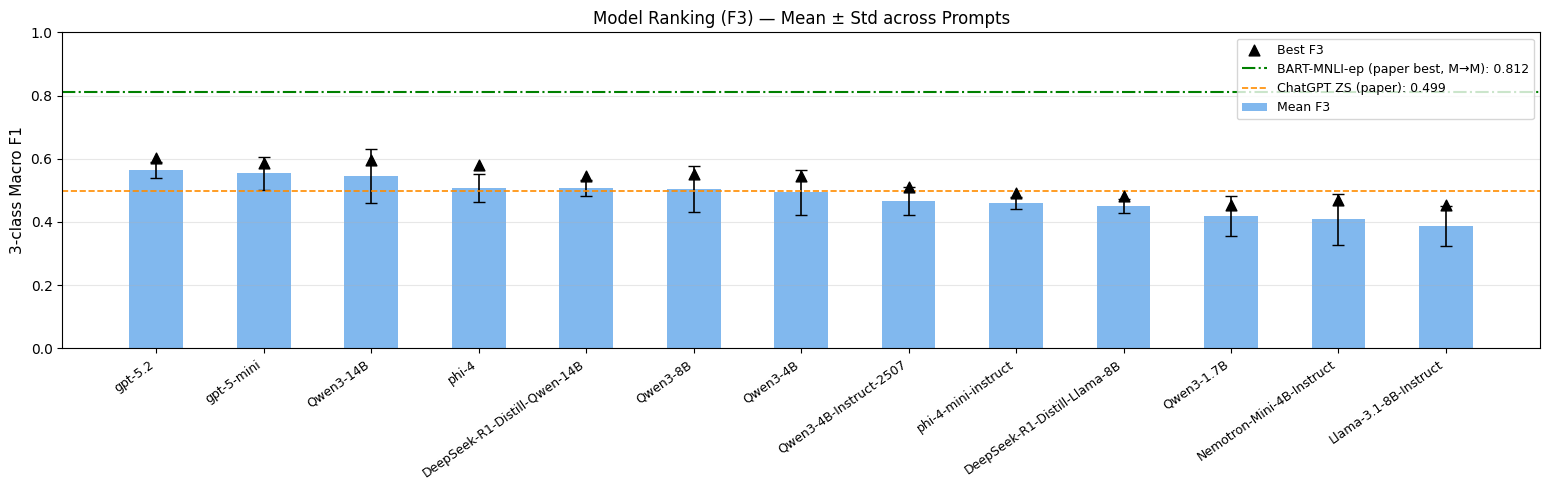


=== Ranking Table ===
                 model_short mean_f3 best_f3 std_f3 mean_f1_favor mean_f1_against mean_f1_none
                     gpt-5.2  0.5637  0.6034 0.0246        0.6378          0.6290       0.4242
                  gpt-5-mini  0.5537  0.5874 0.0514        0.6462          0.6744       0.3405
                   Qwen3-14B  0.5451  0.5949 0.0846        0.6167          0.5554       0.4631
                       phi-4  0.5074  0.5815 0.0441        0.5814          0.5699       0.3710
DeepSeek-R1-Distill-Qwen-14B  0.5073  0.5455 0.0250        0.5715          0.5339       0.4166
                    Qwen3-8B  0.5047  0.5532 0.0723        0.5875          0.5253       0.4014
                    Qwen3-4B  0.4933  0.5451 0.0714        0.6002          0.5535       0.3262
      Qwen3-4B-Instruct-2507  0.4675  0.5108 0.0441        0.5859          0.5432       0.2735
         phi-4-mini-instruct  0.4606  0.4907 0.0194        0.5562          0.5174       0.3082
DeepSeek-R1-Distill-Llama-8

In [ ]:
ranking = (
    llm_df.groupby("model")
    .agg(
        mean_f3        =("3class_macro_f1", "mean"),
        best_f3        =("3class_macro_f1", "max"),
        std_f3         =("3class_macro_f1", "std"),
        mean_f1_favor  =("f_favor",         "mean"),
        mean_f1_against=("f_against",       "mean"),
        mean_f1_none   =("f_none",          "mean"),
    )
    .reset_index()
    .sort_values("mean_f3", ascending=False)
)
ranking["model_short"] = ranking["model"].apply(lambda m: m.split("/")[-1] if "/" in m else m)
ranking["mean_f3"]     = ranking["mean_f3"].map("{:.4f}".format)
ranking["best_f3"]     = ranking["best_f3"].map("{:.4f}".format)
ranking["std_f3"]      = ranking["std_f3"].map("{:.4f}".format)
ranking["mean_f1_favor"]   = ranking["mean_f1_favor"].map("{:.4f}".format)
ranking["mean_f1_against"] = ranking["mean_f1_against"].map("{:.4f}".format)
ranking["mean_f1_none"]    = ranking["mean_f1_none"].map("{:.4f}".format)

n = len(ranking)
x = np.arange(n)
mean_f3_num = ranking["mean_f3"].astype(float)
best_f3_num = ranking["best_f3"].astype(float)
std_f3_num  = ranking["std_f3"].astype(float)

fig, ax = plt.subplots(figsize=(max(12, n * 1.2), 5))
ax.bar(x, mean_f3_num, width=0.5, color="#4C9BE8", alpha=0.7, label="Mean F3")
ax.errorbar(x, mean_f3_num, yerr=std_f3_num,
            fmt="none", color="black", capsize=4, linewidth=1.2)
ax.scatter(x, best_f3_num, marker="^", s=60, color="black", zorder=5, label="Best F3")
ax.axhline(BEST_PAPER_F3, color="green", linestyle="-.", linewidth=1.5,
           label=f"BART-MNLI-ep (paper best, M→M): {BEST_PAPER_F3}")
ax.axhline(CHATGPT_F3, color="darkorange", linestyle="--", linewidth=1.2,
           label=f"ChatGPT ZS (paper): {CHATGPT_F3}")
ax.set_xticks(x)
ax.set_xticklabels(ranking["model_short"], rotation=35, ha="right", fontsize=9)
ax.set_ylim(0, 1)
ax.set_ylabel("3-class Macro F1", fontsize=11)
ax.set_title("Model Ranking (F3) — Mean ± Std across Prompts", fontsize=12)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Ranking Table ===")
cols = ["model_short","mean_f3","best_f3","std_f3","mean_f1_favor","mean_f1_against","mean_f1_none"]
print(ranking[cols].to_string(index=False))

## Step 13: Prompt Sensitivity

**Table 13a** — per model: std F3, best/worst prompt, F3 range.
**Plot 13b** — F3 range per model (sorted by range descending).
**Table 13c** — per prompt: mean F3 across all models.

=== Table 13a: Per-model Prompt Sensitivity ===
                 model_short  std_f3  best_f3  worst_f3  range_f3                  best_prompt          worst_prompt
   Nemotron-Mini-4B-Instruct  0.0809   0.4690    0.1700    0.2990                      default task_definition_scale
                   Qwen3-14B  0.0846   0.5949    0.2967    0.2982                      default task_definition_scale
                    Qwen3-8B  0.0723   0.5532    0.2942    0.2590                      default task_definition_scale
                    Qwen3-4B  0.0714   0.5451    0.2884    0.2567                      default task_definition_scale
       Llama-3.1-8B-Instruct  0.0641   0.4539    0.2198    0.2341 default_no_label_definitions task_definition_scale
                  Qwen3-1.7B  0.0634   0.4540    0.2333    0.2207                          cot task_definition_scale
                  gpt-5-mini  0.0514   0.5874    0.4104    0.1770              task_definition task_definition_scale
      Qwen3-4B-I

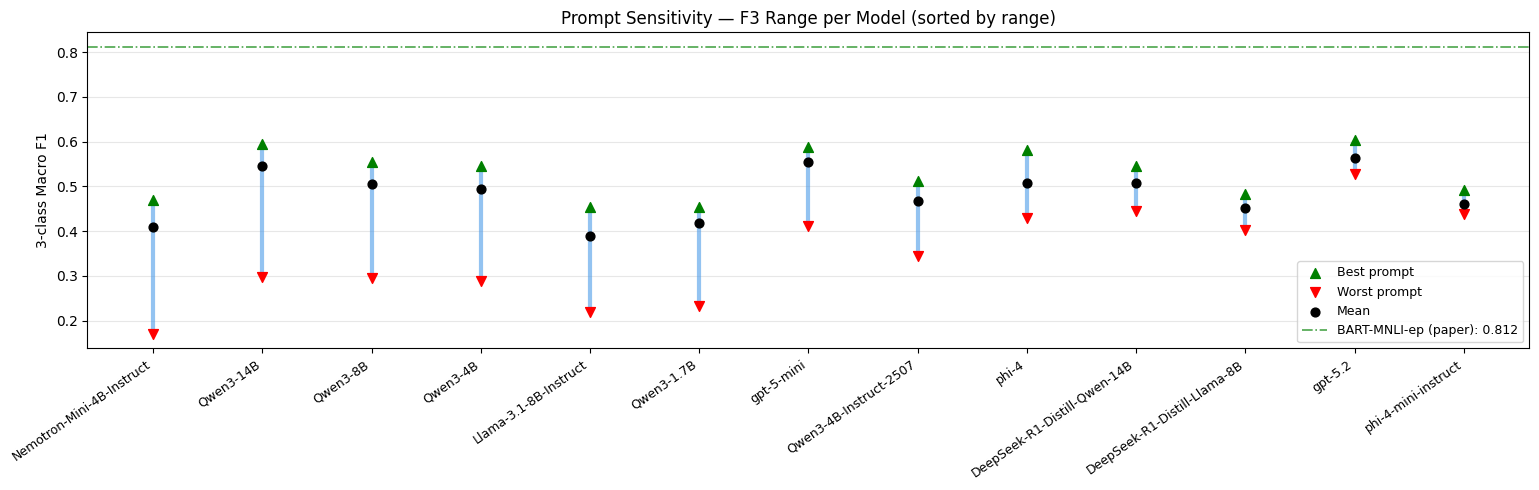


=== Table 13c: Per-prompt mean F3 across all models ===
                              mean_f3  std_f3  best_f3       group
prompt                                                            
default_no_label_definitions   0.4947  0.0464   0.5797   Zero-shot
default                        0.5271  0.0566   0.6034   Zero-shot
task_definition                0.5187  0.0589   0.6033   Zero-shot
question                       0.4732  0.0420   0.5346   Zero-shot
cot                            0.4942  0.0565   0.5802   Zero-shot
task_definition_scale          0.3484  0.1081   0.5272   Zero-shot
few_shot_3                     0.4883  0.0712   0.5821  Random ICL
few_shot_6                     0.4877  0.0643   0.5722  Random ICL
few_shot_9                     0.4904  0.0610   0.5748  Random ICL
few_shot_12                    0.4903  0.0581   0.5732  Random ICL
few_shot_15                    0.4918  0.0544   0.5707  Random ICL


In [ ]:
ZERO_SHOT_PROMPTS  = ["default_no_label_definitions", "default", "task_definition",
                       "question", "cot", "task_definition_scale"]
RANDOM_ICL_PROMPTS = ["few_shot_3", "few_shot_6", "few_shot_9", "few_shot_12", "few_shot_15"]
PROMPT_GROUP = {**{p: "Zero-shot" for p in ZERO_SHOT_PROMPTS},
                **{p: "Random ICL" for p in RANDOM_ICL_PROMPTS}}

sens_rows = []
for model in _ordered_models(llm_df):
    mdf = llm_df[llm_df["model"] == model]
    sens_rows.append({
        "model":        model,
        "mean_f3":      mdf["3class_macro_f1"].mean(),
        "std_f3":       mdf["3class_macro_f1"].std(),
        "best_f3":      mdf["3class_macro_f1"].max(),
        "worst_f3":     mdf["3class_macro_f1"].min(),
        "range_f3":     mdf["3class_macro_f1"].max() - mdf["3class_macro_f1"].min(),
        "best_prompt":  mdf.loc[mdf["3class_macro_f1"].idxmax(), "prompt"],
        "worst_prompt": mdf.loc[mdf["3class_macro_f1"].idxmin(), "prompt"],
    })
sens_df = pd.DataFrame(sens_rows).sort_values("range_f3", ascending=False)
sens_df["model_short"] = sens_df["model"].apply(lambda m: m.split("/")[-1] if "/" in m else m)

print("=== Table 13a: Per-model Prompt Sensitivity ===")
cols_s = ["model_short", "std_f3", "best_f3", "worst_f3", "range_f3", "best_prompt", "worst_prompt"]
print(sens_df[cols_s].to_string(index=False, float_format="{:.4f}".format))

n = len(sens_df)
x = np.arange(n)
fig, ax = plt.subplots(figsize=(max(10, n * 1.2), 5))
ax.vlines(x, sens_df["worst_f3"], sens_df["best_f3"],
          color="#4C9BE8", linewidth=3, alpha=0.6)
ax.scatter(x, sens_df["best_f3"],  marker="^", color="green",  s=50, zorder=5, label="Best prompt")
ax.scatter(x, sens_df["worst_f3"], marker="v", color="red",    s=50, zorder=5, label="Worst prompt")
ax.scatter(x, sens_df["mean_f3"],  marker="o", color="black",  s=40, zorder=6, label="Mean")
ax.axhline(BEST_PAPER_F3, color="green", linestyle="-.", linewidth=1.2, alpha=0.7,
           label=f"BART-MNLI-ep (paper): {BEST_PAPER_F3}")
ax.set_xticks(x)
ax.set_xticklabels(sens_df["model_short"], rotation=35, ha="right", fontsize=9)
ax.set_ylabel("3-class Macro F1")
ax.set_title("Prompt Sensitivity — F3 Range per Model (sorted by range)")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Table 13c: Per-prompt mean F3 across all models ===")
avail = [p for p in PROMPT_ORDER if p in llm_df["prompt"].unique()]
prom_tbl = (
    llm_df[llm_df["prompt"].isin(avail)]
    .groupby("prompt")["3class_macro_f1"]
    .agg(["mean", "std", "max"])
    .reindex(avail)
    .rename(columns={"mean": "mean_f3", "std": "std_f3", "max": "best_f3"})
)
prom_tbl["group"] = prom_tbl.index.map(PROMPT_GROUP)
print(prom_tbl.round(4).to_string())

## Step 14: F3 by Prompt Family — Grouped Bar Chart

Three families: **Label Defs** (zero-shot label variants), **Reasoning** (question / CoT / scale), **Random ICL** (3–15 shots).
Bar = mean F3 for that family per model. Horizontal lines = individual prompt F3. Red dashed = paper best.

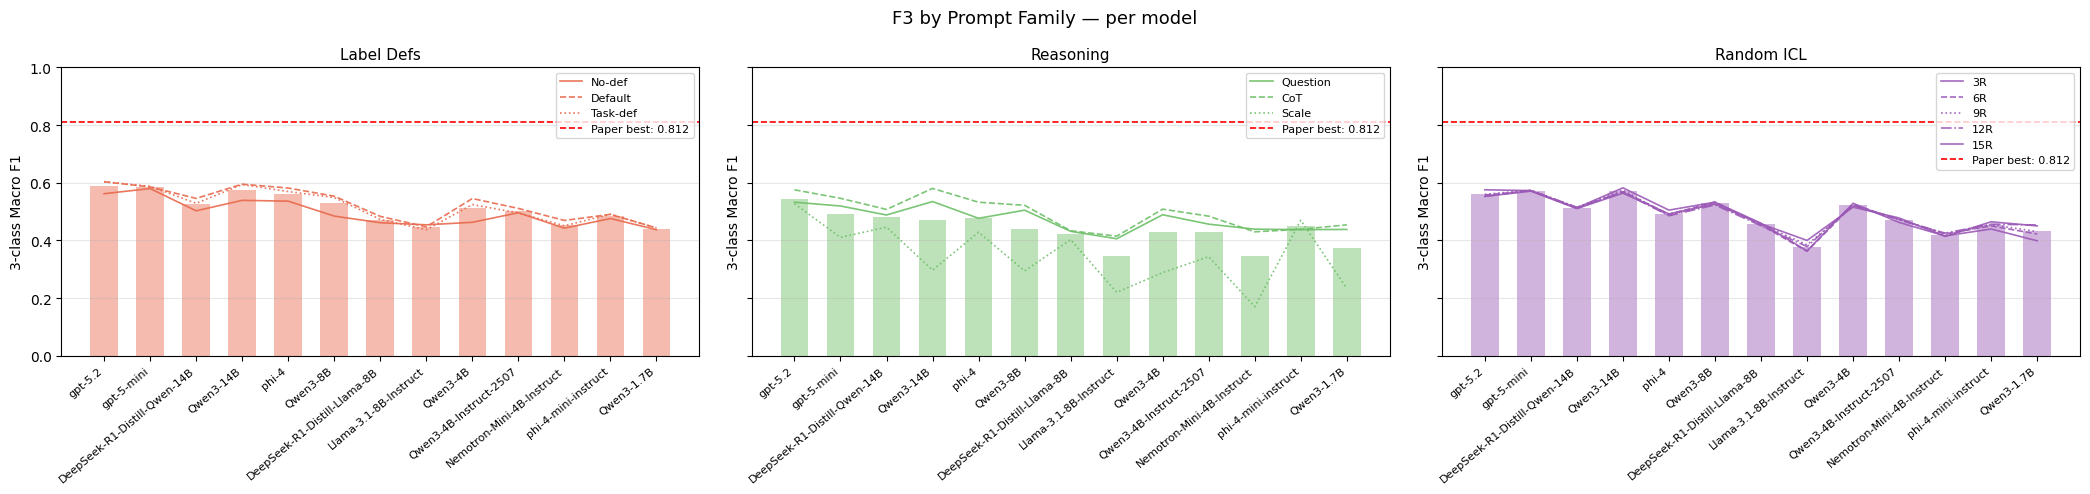

In [ ]:
FAMILIES = OrderedDict([
    ("Label Defs", {
        "prompts": ["default_no_label_definitions", "default", "task_definition"],
        "labels":  ["No-def", "Default", "Task-def"],
        "color":   "#E8694C", "styles": ["-", "--", ":"],
    }),
    ("Reasoning", {
        "prompts": ["question", "cot", "task_definition_scale"],
        "labels":  ["Question", "CoT", "Scale"],
        "color":   "#6DBF67", "styles": ["-", "--", ":"],
    }),
    ("Random ICL", {
        "prompts": ["few_shot_3","few_shot_6","few_shot_9","few_shot_12","few_shot_15"],
        "labels":  ["3R","6R","9R","12R","15R"],
        "color":   "#9B59B6", "styles": ["-","--",":","-.","-"],
    }),
])

avail_models = _ordered_models(llm_df)
avail_model_labels = [m.split("/")[-1] if "/" in m else m for m in avail_models]
x = np.arange(len(avail_models))
bar_w = 0.6

fig, axes = plt.subplots(1, len(FAMILIES), figsize=(7 * len(FAMILIES), 5), sharey=True)
fig.suptitle("F3 by Prompt Family — per model", fontsize=13)

for ax, (fam_name, fam) in zip(axes, FAMILIES.items()):
    fam_prompts = [p for p in fam["prompts"] if p in llm_df["prompt"].unique()]
    if not fam_prompts:
        ax.set_title(fam_name)
        continue

    means = [llm_df[(llm_df["model"] == m) & (llm_df["prompt"].isin(fam_prompts))]["3class_macro_f1"].mean()
             for m in avail_models]
    ax.bar(x, means, width=bar_w, color=fam["color"], alpha=0.45)

    for pj, prompt in enumerate(fam_prompts):
        ys = []
        for xi, model in enumerate(avail_models):
            row = llm_df[(llm_df["model"] == model) & (llm_df["prompt"] == prompt)]
            ys.append(row["3class_macro_f1"].values[0] if len(row) else float("nan"))
        ax.plot(x, ys, color=fam["color"],
                linestyle=fam["styles"][pj % len(fam["styles"])],
                linewidth=1.2, alpha=0.9,
                label=fam["labels"][pj])

    ax.axhline(BEST_PAPER_F3, color="red", linestyle="--", linewidth=1.2,
               label=f"Paper best: {BEST_PAPER_F3}")
    ax.set_title(fam_name, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(avail_model_labels, rotation=40, ha="right", fontsize=8)
    ax.set_ylabel("3-class Macro F1")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

#
#
 
S
t
e
p
 
1
5
:
 
P
e
r
-
d
o
m
a
i
n
 
M
a
c
r
o
 
F
1
 
A
n
a
l
y
s
i
s


8
 
E
Z
S
t
a
n
c
e
 
d
o
m
a
i
n
s
:
 
*
*
C
E
*
*
 
(
C
o
v
i
d
 
E
p
i
d
e
m
i
c
)
,
 
*
*
W
E
*
*
 
(
W
o
r
l
d
 
E
v
e
n
t
s
)
,
 
*
*
E
d
C
*
*
 
(
E
d
u
c
a
t
i
o
n
 
&
 
C
u
l
t
u
r
e
)
,

*
*
E
n
C
*
*
 
(
E
n
t
e
r
t
a
i
n
m
e
n
t
 
&
 
C
o
n
s
u
m
p
t
i
o
n
)
,
 
*
*
S
*
*
 
(
S
p
o
r
t
s
)
,
 
*
*
R
*
*
 
(
R
i
g
h
t
s
)
,
 
*
*
E
P
*
*
 
(
E
n
v
i
r
o
n
m
e
n
t
a
l
 
P
r
o
t
e
c
t
i
o
n
)
,
 
*
*
P
*
*
 
(
P
o
l
i
t
i
c
s
)
.

In [ ]:
gold_claim = pd.read_csv(GOLD_CSV)
gold_claim = gold_claim[gold_claim["source_dataset"] == "EZStance-SubtaskA-Claim-test"].copy()
gold_claim["gold"] = gold_claim["stance_label_original"].apply(canonicalize)
gold_claim["id"]   = gold_claim["id"].astype(str)

domain_rows = []
for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_7798"):
        continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists():
        continue
    model, prompt = extract_model_prompt(folder)
    if model is None or prompt not in PROMPT_ORDER:
        continue

    preds = pd.read_csv(csv_path)
    preds = preds[preds["doc_id"].astype(str).isin(CLAIM_IDS)].copy()
    preds["pred"] = preds["predicted_stance"].apply(
        lambda x: canonicalize(x) if pd.notna(x) else None
    )
    preds["id"] = preds["doc_id"].astype(str)
    merged = preds[["id","pred"]].merge(gold_claim[["id","gold","domain"]], on="id")
    merged = merged[merged["pred"].isin(CLASSES)]

    for domain in DOMAIN_ORDER:
        sub = merged[merged["domain"] == domain]
        if len(sub) == 0:
            continue
        _, _, f, _ = precision_recall_fscore_support(
            sub["gold"], sub["pred"], labels=CLASSES, average=None, zero_division=0
        )
        domain_rows.append({
            "model": model, "prompt": prompt, "domain": domain,
            "macro_f1": f.mean(), "f_favor": f[0], "f_against": f[1], "f_none": f[2],
        })

domain_df = pd.DataFrame(domain_rows)
print(f"Loaded {len(domain_df)} model×prompt×domain rows")
print("\nMean macro F1 per domain (across all model×prompt):")
print(domain_df.groupby("domain")["macro_f1"].mean().reindex(DOMAIN_ORDER).round(3).to_string())

### Chart: Per-domain Macro F1 — each model, mean across prompts

/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_19259/1867072345.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_dom   = plt.cm.get_cmap("tab10", max(len(models_dom), 2))


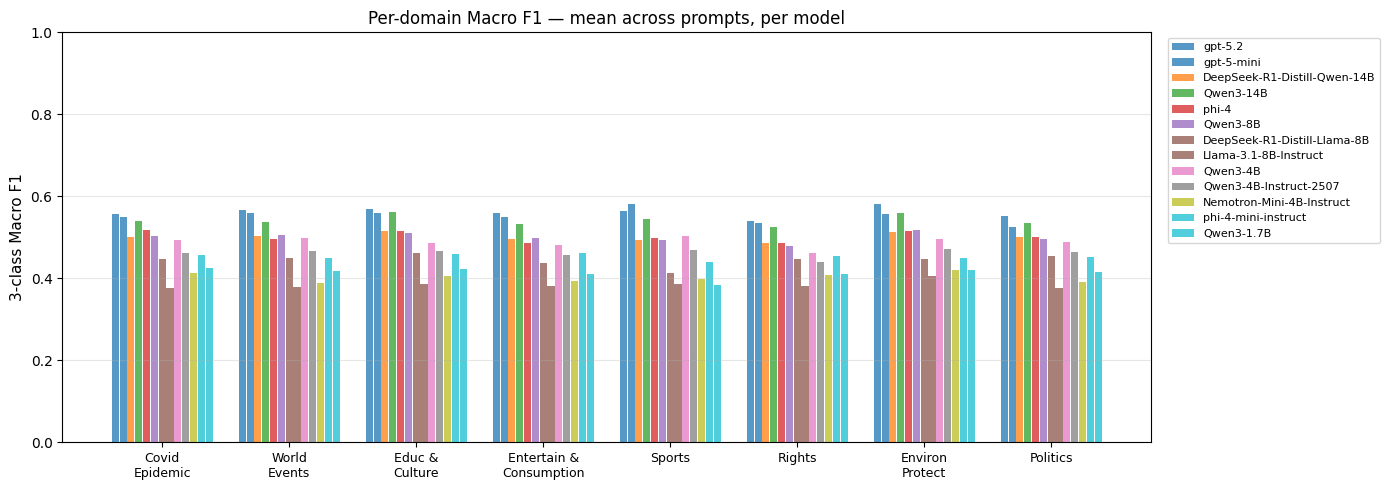

In [ ]:
domain_mean = (
    domain_df.groupby(["model","domain"])["macro_f1"].mean().reset_index()
)
models_dom = _ordered_models(domain_df)
cmap_dom   = plt.cm.get_cmap("tab10", max(len(models_dom), 2))
x = np.arange(len(DOMAIN_ORDER))
bar_w_dom  = 0.8 / max(len(models_dom), 1)

fig, ax = plt.subplots(figsize=(14, 5))
for i, model in enumerate(models_dom):
    mdf = domain_mean[domain_mean["model"] == model].set_index("domain")
    y = [mdf.loc[d, "macro_f1"] if d in mdf.index else float("nan") for d in DOMAIN_ORDER]
    short  = model.split("/")[-1] if "/" in model else model
    offset = (i - len(models_dom)/2 + 0.5) * bar_w_dom
    ax.bar(x + offset, y, width=bar_w_dom * 0.9, color=cmap_dom(i), alpha=0.75, label=short)

ax.set_xticks(x)
ax.set_xticklabels([DOMAIN_NAMES.get(d, d) for d in DOMAIN_ORDER], fontsize=9)
ax.set_ylim(0, 1)
ax.set_ylabel("3-class Macro F1", fontsize=11)
ax.set_title("Per-domain Macro F1 — mean across prompts, per model", fontsize=12)
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Per-domain per-class F1 — best prompt per model

Best prompt per model: {'DeepSeek-R1-Distill-Llama-8B': 'default', 'DeepSeek-R1-Distill-Qwen-14B': 'default', 'Llama-3.1-8B-Instruct': 'default_no_label_definitions', 'Nemotron-Mini-4B-Instruct': 'default', 'Qwen3-1.7B': 'cot', 'Qwen3-14B': 'default', 'Qwen3-4B-Instruct-2507': 'default', 'Qwen3-4B': 'default', 'Qwen3-8B': 'default', 'phi-4-mini-instruct': 'task_definition', 'phi-4': 'default', 'gpt-5-mini': 'task_definition', 'gpt-5.2': 'default'}


/var/folders/10/67s7rjm504qch0mswpljm_yc0000gn/T/ipykernel_19259/648867095.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_sel         = plt.cm.get_cmap("tab10", max(len(models_sel), 2))


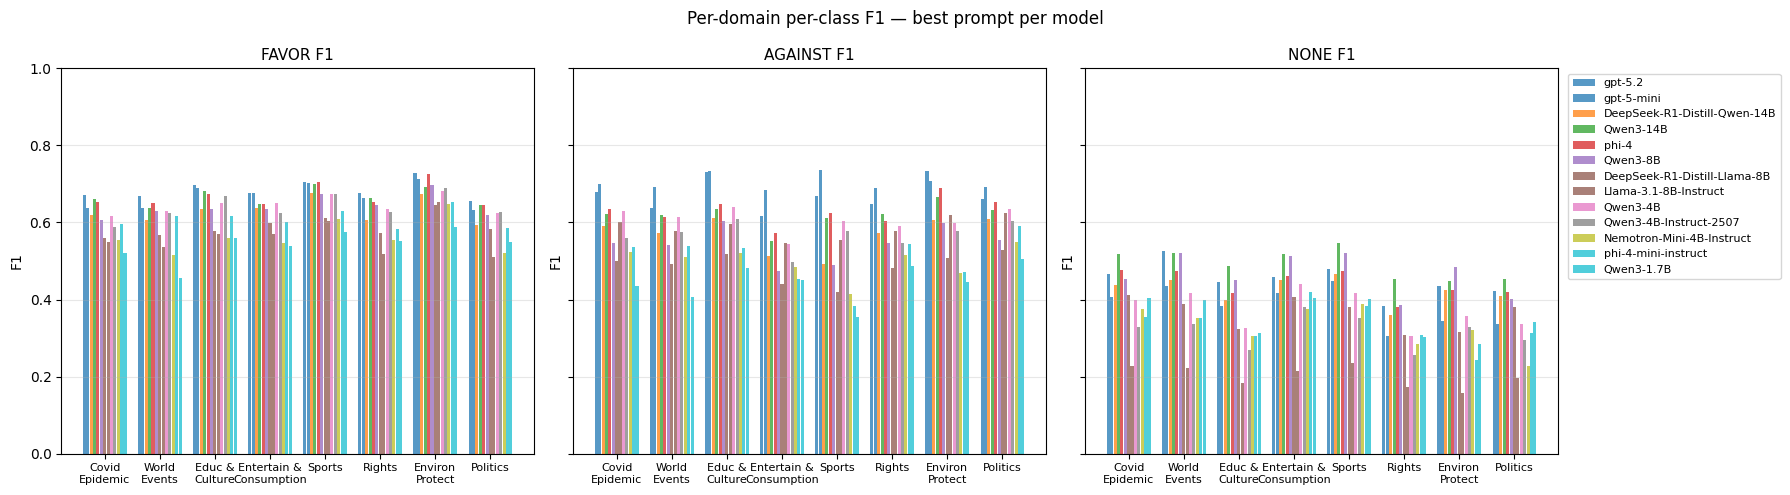

In [ ]:
best_prompts_map = {
    m: llm_df.loc[llm_df[llm_df["model"] == m]["3class_macro_f1"].idxmax(), "prompt"]
    for m in llm_df["model"].unique()
}
print("Best prompt per model:", best_prompts_map)

selected = domain_df[domain_df.apply(
    lambda r: best_prompts_map.get(r["model"]) == r["prompt"], axis=1
)]
models_sel       = _ordered_models(selected)
model_labels_sel = [m.split("/")[-1] if "/" in m else m for m in models_sel]
cmap_sel         = plt.cm.get_cmap("tab10", max(len(models_sel), 2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle("Per-domain per-class F1 — best prompt per model", fontsize=12)

class_cols = [("f_favor","FAVOR"), ("f_against","AGAINST"), ("f_none","NONE")]
for col_idx, (cls_col, cls_name) in enumerate(class_cols):
    ax      = axes[col_idx]
    x       = np.arange(len(DOMAIN_ORDER))
    bar_w_s = 0.8 / max(len(models_sel), 1)
    for i, model in enumerate(models_sel):
        mdf = selected[selected["model"] == model].set_index("domain")
        y   = [mdf.loc[d, cls_col] if d in mdf.index else float("nan") for d in DOMAIN_ORDER]
        short  = model.split("/")[-1] if "/" in model else model
        offset = (i - len(models_sel)/2 + 0.5) * bar_w_s
        ax.bar(x + offset, y, width=bar_w_s * 0.9, color=cmap_sel(i), alpha=0.75, label=short)
    ax.set_xticks(x)
    ax.set_xticklabels([DOMAIN_NAMES.get(d, d) for d in DOMAIN_ORDER], fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_title(f"{cls_name} F1", fontsize=11)
    ax.set_ylabel("F1")
    ax.grid(axis="y", alpha=0.3)

axes[2].legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Domain Ranking Table — which domains are hardest?

In [ ]:
domain_ranking = (
    domain_df.groupby("domain")
    .agg(
        mean_f3       =("macro_f1",  "mean"),
        std_f3        =("macro_f1",  "std"),
        mean_f_favor  =("f_favor",   "mean"),
        mean_f_against=("f_against", "mean"),
        mean_f_none   =("f_none",    "mean"),
    )
    .reindex(DOMAIN_ORDER)
    .sort_values("mean_f3")
)
domain_ranking["domain_name"] = [
    DOMAIN_NAMES.get(d, d).replace("\n", " ") for d in domain_ranking.index
]
print("=== Domain Ranking Table (hardest → easiest) ===")
print(domain_ranking[
    ["domain_name","mean_f3","std_f3","mean_f_favor","mean_f_against","mean_f_none"]
].round(3).to_string())

=== Domain Ranking Table (hardest → easiest) ===
                    domain_name  mean_f3  std_f3  mean_f_favor  mean_f_against  mean_f_none
domain                                                                                     
R                        Rights    0.466   0.069         0.575           0.537        0.285
EnC     Entertain & Consumption    0.473   0.075         0.566           0.463        0.390
P                      Politics    0.473   0.076         0.550           0.560        0.310
S                        Sports    0.474   0.086         0.601           0.433        0.389
WE                 World Events    0.478   0.080         0.537           0.524        0.373
CE               Covid Epidemic    0.480   0.077         0.547           0.528        0.365
EdC              Educ & Culture    0.486   0.081         0.585           0.551        0.323
EP              Environ Protect    0.489   0.080         0.638           0.531        0.298


#
#
 
S
t
e
p
 
1
6
:
 
P
e
r
-
d
o
m
a
i
n
 
C
o
n
f
u
s
i
o
n
 
T
r
a
n
s
i
t
i
o
n
 
H
e
a
t
m
a
p


S
a
m
e
 
6
 
t
r
a
n
s
i
t
i
o
n
s
,
 
b
r
o
k
e
n
 
o
u
t
 
p
e
r
 
d
o
m
a
i
n
.
 
V
a
l
u
e
s
 
=
 
m
e
a
n
 
t
r
a
n
s
i
t
i
o
n
 
r
a
t
e
 
a
c
r
o
s
s
 
a
l
l
 
p
r
o
m
p
t
s
 
p
e
r
 
m
o
d
e
l
.

R
e
v
e
a
l
s
 
w
h
e
t
h
e
r
 
h
e
d
g
i
n
g
 
(
A
G
A
I
N
S
T
→
N
O
N
E
)
 
a
n
d
 
a
g
r
e
e
a
b
l
e
n
e
s
s
 
(
F
A
V
O
R
 
b
i
a
s
)
 
a
r
e
 
d
o
m
a
i
n
-
c
o
n
d
i
t
i
o
n
e
d
.

In [ ]:
dom_cm_rows = []
for folder in sorted(os.listdir(RESULTS_DIR)):
    if not folder.startswith("GenAIStanceOneShot_7798"):
        continue
    csv_path = RESULTS_DIR / folder / "document_assignments.csv"
    if not csv_path.exists():
        continue
    model, prompt = extract_model_prompt(folder)
    if model is None or prompt not in PROMPT_ORDER:
        continue

    preds = pd.read_csv(csv_path)
    preds["pred"] = preds["predicted_stance"].apply(
        lambda x: canonicalize(x) if pd.notna(x) else None
    )
    preds = preds[preds["doc_id"].astype(str).isin(CLAIM_IDS)].copy()
    preds["id"] = preds["doc_id"].astype(str)
    merged = preds[["id","pred"]].merge(gold_claim[["id","gold","domain"]], on="id")
    merged = merged[merged["pred"].isin(CLASSES) & merged["gold"].isin(CLASSES)]
    short = model.split("/")[-1] if "/" in model else model

    for domain in DOMAIN_ORDER:
        sub = merged[merged["domain"] == domain]
        if len(sub) < 10:
            continue
        cm      = confusion_matrix(sub["gold"], sub["pred"], labels=CLASSES).astype(float)
        row_sum = cm.sum(axis=1, keepdims=True)
        cm_norm = np.divide(cm, row_sum, where=row_sum > 0)

        row = {"model": model, "model_short": short, "prompt": prompt, "domain": domain}
        for ri, tc in enumerate(CLASSES):
            for ci, pc in enumerate(CLASSES):
                row[f"{tc}→{pc}"] = cm_norm[ri, ci]
        dom_cm_rows.append(row)

dom_cm_df = pd.DataFrame(dom_cm_rows)

model_order_hm = _ordered_models(llm_df)

fig, axes = plt.subplots(2, 4, figsize=(30, 10),
                         gridspec_kw={"hspace": 0.45, "wspace": 0.35})
fig.suptitle("Per-domain Confusion Transitions — Claim-Only (mean across prompts per model)", fontsize=13)

for di, domain in enumerate(DOMAIN_ORDER):
    ax  = axes[di // 4][di % 4]
    sub = dom_cm_df[dom_cm_df["domain"] == domain]
    if len(sub) == 0:
        ax.set_title(DOMAIN_NAMES.get(domain, domain).replace("\n", " "))
        ax.axis("off")
        continue

    mean_trans = (
        sub.groupby("model")[KEY_TRANS].mean()
        .reindex([m for m in model_order_hm if m in sub["model"].unique()])
    )
    hmap     = mean_trans.values
    row_lbls = [m.split("/")[-1] if "/" in m else m for m in mean_trans.index]

    im = ax.imshow(hmap, aspect="auto", cmap="YlOrRd", vmin=0, vmax=1.0)
    ax.set_xticks(range(len(KEY_TRANS)))
    ax.set_xticklabels(KEY_TRANS, fontsize=6, rotation=30, ha="right")
    ax.set_yticks(range(len(row_lbls)))
    ax.set_yticklabels(row_lbls, fontsize=6)
    ax.set_title(DOMAIN_NAMES.get(domain, domain).replace("\n", " "), fontsize=9)

    for r in range(hmap.shape[0]):
        for c in range(hmap.shape[1]):
            val = hmap[r, c]
            ax.text(c, r, f"{val:.2f}", ha="center", va="center",
                    fontsize=4.5, color="black" if val < 0.55 else "white")

plt.colorbar(im, ax=axes.ravel().tolist(), fraction=0.015, pad=0.02,
             label="Fraction of gold class")
plt.show()

In [ ]:
# ── Table for Per-domain Confusion Heatmap ───────────────────────────
print("=== Per-domain confusion transitions (mean across models and prompts) ===")
_dom_table = dom_cm_df.groupby(["domain", "model_short"])[KEY_TRANS].mean().round(3)
display(_dom_table)
print(_dom_table.to_csv())


=== Per-domain confusion transitions (mean across models and prompts) ===


FAVOR→FAVOR  FAVOR→AGAINST  FAVOR→NONE  \
domain model_short                                                            
CE     DeepSeek-R1-Distill-Llama-8B        0.590          0.150       0.259   
       DeepSeek-R1-Distill-Qwen-14B        0.627          0.144       0.229   
       Llama-3.1-8B-Instruct               0.747          0.226       0.026   
       Nemotron-Mini-4B-Instruct           0.538          0.256       0.206   
       Qwen3-1.7B                          0.651          0.069       0.280   
...                                          ...            ...         ...   
WE     Qwen3-8B                            0.668          0.072       0.260   
       gpt-5-mini                          0.851          0.052       0.097   
       gpt-5.2                             0.778          0.043       0.179   
       phi-4                               0.657          0.147       0.195   
       phi-4-mini-instruct                 0.590          0.295       0.115   

                                     AGAINST→FAVOR  AGAINST→AGAINST  \
domain model_short                                                    
CE     DeepSeek-R1-Distill-Llama-8B          0.298            0.402   
       DeepSeek-R1-Distill-Qwen-14B          0.209            0.495   
       Llama-3.1-8B-Instruct                 0.429            0.544   
       Nemotron-Mini-4B-Instruct             0.276            0.481   
       Qwen3-1.7B                            0.361            0.224   
...                                            ...              ...   
WE     Qwen3-8B                              0.279            0.452   
       gpt-5-mini                            0.270            0.635   
       gpt-5.2                               0.243            0.540   
       phi-4                                 0.240            0.539   
       phi-4-mini-instruct                   0.224            0.628   

                                     AGAINST→NONE  NONE→FAVOR  NONE→AGAINST  \
domain model_short                                                            
CE     DeepSeek-R1-Distill-Llama-8B         0.300       0.470         0.162   
       DeepSeek-R1-Distill-Qwen-14B         0.296       0.418         0.185   
       Llama-3.1-8B-Instruct                0.027       0.656         0.281   
       Nemotron-Mini-4B-Instruct            0.244       0.427         0.269   
       Qwen3-1.7B                           0.416       0.404         0.100   
...                                           ...         ...           ...   
WE     Qwen3-8B                             0.269       0.448         0.121   
       gpt-5-mini                           0.095       0.551         0.167   
       gpt-5.2                              0.217       0.460         0.127   
       phi-4                                0.221       0.459         0.204   
       phi-4-mini-instruct                  0.147       0.384         0.396   

                                     NONE→NONE  
domain model_short                              
CE     DeepSeek-R1-Distill-Llama-8B      0.367  
       DeepSeek-R1-Distill-Qwen-14B      0.397  
       Llama-3.1-8B-Instruct             0.063  
       Nemotron-Mini-4B-Instruct         0.304  
       Qwen3-1.7B                        0.496  
...                                        ...  
WE     Qwen3-8B                          0.431  
       gpt-5-mini                        0.281  
       gpt-5.2                           0.413  
       phi-4                             0.338  
       phi-4-mini-instruct               0.220  

[104 rows x 9 columns]

domain,model_short,FAVOR→FAVOR,FAVOR→AGAINST,FAVOR→NONE,AGAINST→FAVOR,AGAINST→AGAINST,AGAINST→NONE,NONE→FAVOR,NONE→AGAINST,NONE→NONE
CE,DeepSeek-R1-Distill-Llama-8B,0.59,0.15,0.259,0.298,0.402,0.3,0.47,0.162,0.367
CE,DeepSeek-R1-Distill-Qwen-14B,0.627,0.144,0.229,0.209,0.495,0.296,0.418,0.185,0.397
CE,Llama-3.1-8B-Instruct,0.747,0.226,0.026,0.429,0.544,0.027,0.656,0.281,0.063
CE,Nemotron-Mini-4B-Instruct,0.538,0.256,0.206,0.276,0.481,0.244,0.427,0.269,0.304
CE,Qwen3-1.7B,0.651,0.069,0.28,0.361,0.224,0.416,0.404,0.1,0.496
CE,Qwen3-14B,0.718,0.067,0.215,0.241,0.475,0.285,0.433,0.11,0.458
CE,Qwen3-4B,0.794,0.082,0.123,0.332,0.513,0.154,0.576,0.161,0.263
CE,Qwen3-4B-Instruct-2507,0.74,0.16,0.1,0.331,0.54,0.128,0.546,0.244,0.209
CE,Qwen3-8B,0.732,0.073,0.195,0.301,0.454,0.245,0.52,0.112,0.369
CE,gpt-5-mini,0.863,0.073,0.064,0.277,0.625,0.099,0.572,0.165,0.264
CE,gpt-5.2,0.8,0.078,0.122,0.249,0.555,0.195,0.486,0.147,0.367
CE,phi-4,0.689,0.144,0.167,0.248,0.554,0.198,0.466,0.182,0.352
CE,phi-